In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append("../")

In [32]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from phonetics import plots as plots

In [ ]:
# # High-resolution plots in Jupyter
# %config InlineBackend.figure_format = 'retina'

# # Use LaTeX-style fonts for text rendering
# plt.rcParams.update({
#     "text.usetex": True,
#     "font.family": "serif",
#     "font.serif": ["Computer Modern Roman"],  # or Times, Palatino, etc.
#     "axes.labelsize": 12,
#     "axes.titlesize": 14,
#     "xtick.labelsize": 11,
#     "ytick.labelsize": 11
# })

# Dictionary

In [40]:
root = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/experiments/3D'
d = {
    'ES': {
        #'exp': 'gt_singer_ES_v0',
        #'exp': 'gt_singer_ES_v0_edna',
        'exp': 'gt_singer_ES_long_3d_v1',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's'],#, 'm', 'n'],
        'name': 'Spanish'
    },
    'FR': {
        'exp': 'gt_singer_FR_3d_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's'],#, 'm', 'n'],
        'name': 'French'
    },
    'IT': {
        'exp': 'gt_singer_IT_3d_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's'],#, 'm', 'n'],
        'name': 'Italian'
    },
    'EN': {
        'exp': 'gt_singer_EN_3d_v0',
        'phones': ['<AP>', '<SP>', 'AY', 'IY', 'EY', 'OW', 'UW', 'S'], # 'M', 'N',
        'name': 'English'
    },
    'DE': {
        'exp': 'gt_singer_DE_3d_v0',
        'phones': ['<AP>', '<SP>', 'a', 'ə', 'iː', 'o:', 'ʊ', 's'], #, 'm', 'n'],
        'name': 'German'
    },
    'RU': {
        'exp': 'gt_singer_RU_3d_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'u', 's̪'], #, 'm', 'n̪'],
        'name': 'Russian'
    },
    'JA': {
        'exp': 'gt_singer_JA_3d_v0',
        'phones': ['<AP>', '<SP>', 'a', 'e', 'i', 'o', 'ɯ', 's'], #, 'm', 'n'],
        'name': 'Japanese'
    },
    'KO': {
        'exp': 'gt_singer_KO_3d_v0',
        'phones': ['<AP>', '<SP>', 'ɐ', 'ɛː', 'i', 'o', 'u',  'sʰ'], #, 'm', 'n'],
        'name': 'Korean'
    },
    'ZH': {
        'exp': 'gt_singer_ZH_3d_v0',
        'phones': ['<AP>', '<SP>', 'ai', 'e', 'i', 'uo', 'u', 'sh'], #, 'm', 'n'],
        'name': 'Chinese'
    }
    #
}

In [41]:
for k in d.keys():
    experiment_path = f'{root}/{d[k]["exp"]}'
    feat_3d_path = f'{experiment_path}/feat_3d/feat_3d_layer_10.csv'

    df_anotated_3d = pd.read_csv(feat_3d_path, index_col=0)
    d[k]['all_phones'] = [k for k in df_anotated_3d['phone_base'].value_counts().keys()]

In [42]:
def center_df(df):
    df = df.copy()
    df['x'] = df['x'] - df['x'].mean()
    df['y'] = df['y'] - df['y'].mean()
    df['z'] = df['z'] - df['z'].mean()

    return df

def filter_by_distance(df):
    df = df.copy()
    df['dist'] = np.sqrt(df['x']**2 + df['y']**2 + df['z']**2)

    mask = df['dist'] < 8

    return df[mask]

In [46]:
root_output = '/Users/tomasandrade/Documents/BSC/ICHOIR/applio/Applio_LS/siggraph/LS_3d'
os.makedirs(root_output)

In [51]:
def make_simple_3d_plot(lang, lang_d):
    
    experiment_path = f'{root}/{lang_d[lang]["exp"]}'
    feat_path = f'{experiment_path}/feat_3d/feat_3d_layer_10.csv'

    df_anotated = pd.read_csv(feat_path, index_col=0)
    unique_phones = d[lang]['phones']

    mask = df_anotated['phone_base'].isin(unique_phones)
    df = df_anotated[mask]
    df_small = df[['x', 'y', 'z', 'phone_base']]

    df_small = center_df(df_small)
    df_small = filter_by_distance(df_small)
    df_small = df[['x', 'y', 'z', 'phone_base']]

    df_small.to_csv(f'{root_output}/LS_{lang}_clean.csv')

    plots.make_tagged_LS_plot(df_small,
                        phones = unique_phones,
                        alpha = 0.1, 
                        s = 0.2,
                        show_global=False,
                        align_head=True,
                        add_legend = True,
                        save_csv = None)

Making a 3d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot
Making a 3d plot


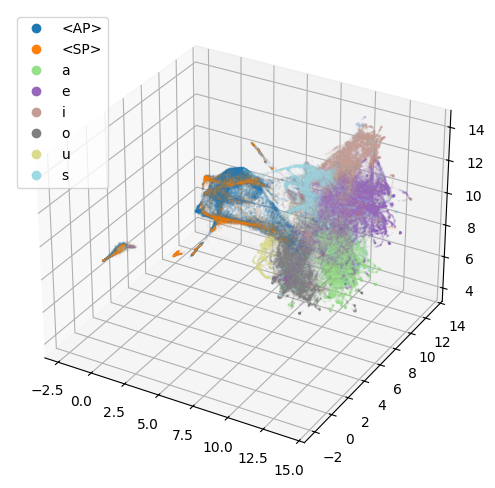

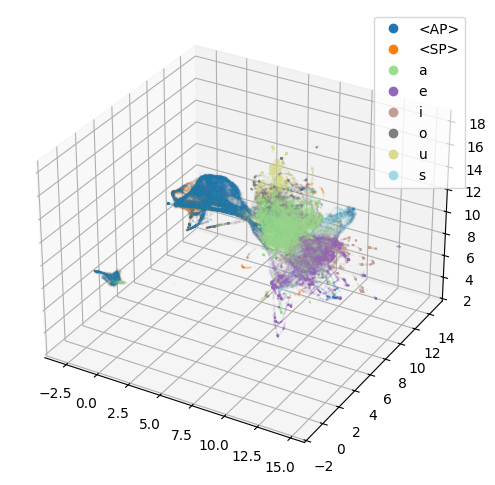

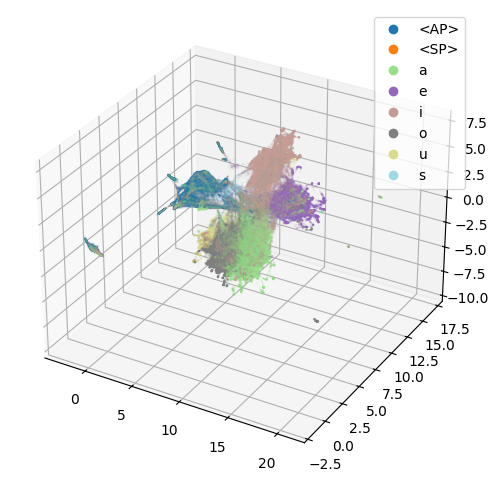

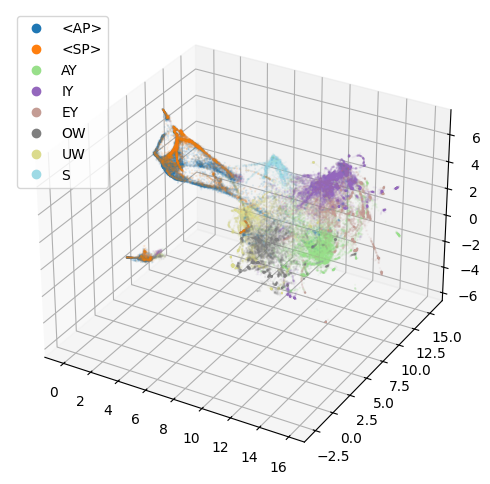

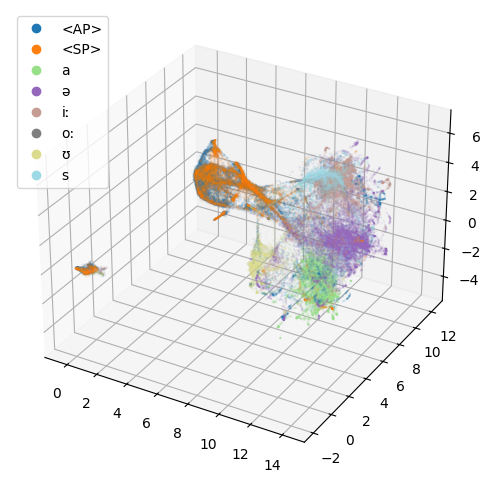

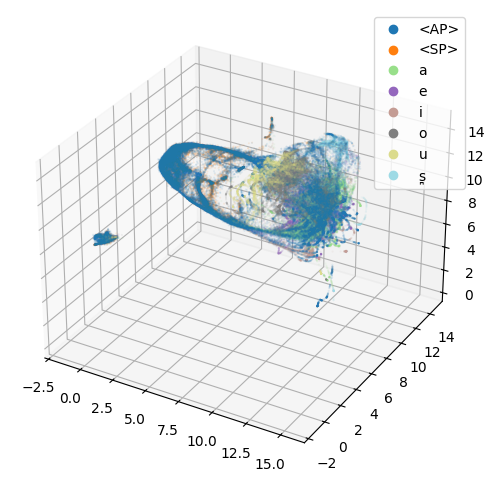

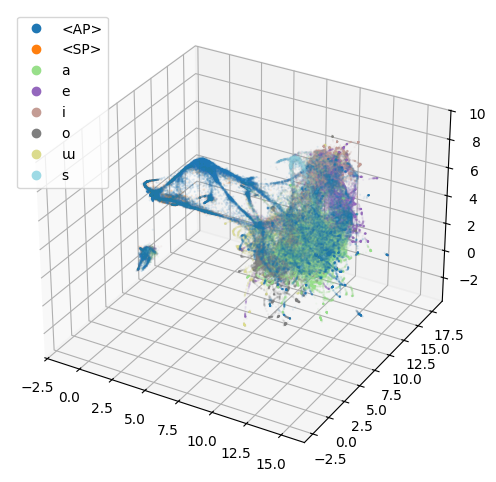

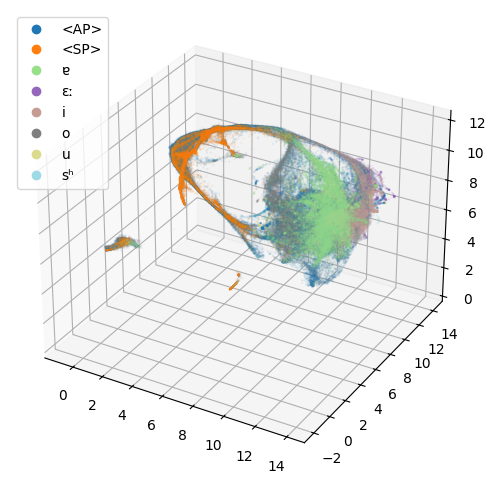

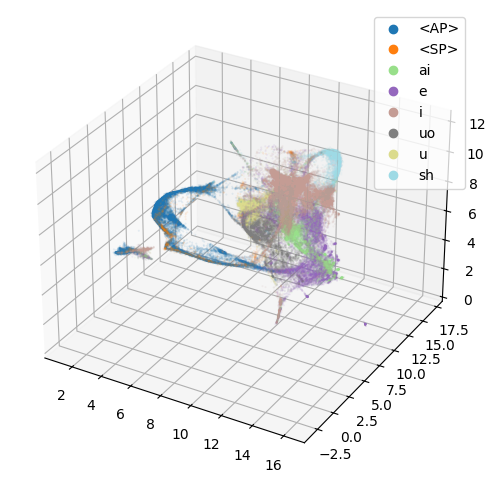

In [52]:
for k in d.keys():
    make_simple_3d_plot(k, d)